# 04 - Evaluation on Testing Day
## CICDDoS2019 Multi-Class DDoS Detection

**Input:** cleaned_test.pkl, models/xgboost_ddos_model.json, training_results.pkl
**Output:** Confusion matrix, per-class metrics, overall accuracy

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
print('OK')

OK


## 1. Load Test Data & Model

In [2]:
# Load test data
with open('../data/cleaned_test.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_test = test_data['X']
y_test_raw = test_data['y']
all_classes = test_data['classes']

# Load training results (for label mapping)
with open('../data/training_results.pkl', 'rb') as f:
    train_results = pickle.load(f)

train_classes = train_results['classes']
label_map_train = train_results['label_map']  # original_id -> training_id

print(f'Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features')
print(f'All classes in test: {all_classes}')
print(f'Training classes: {train_classes}')

Test set: 201,950 samples, 82 features
All classes in test: [np.str_('BENIGN'), np.str_('DNS'), np.str_('LDAP'), np.str_('MSSQL'), np.str_('NETBIOS'), np.str_('NTP'), np.str_('PORTMAP'), np.str_('SNMP'), np.str_('SSDP'), np.str_('SYN'), np.str_('TFTP'), np.str_('UDP'), np.str_('UDP-LAG'), np.str_('WEBDDOS')]
Training classes: [np.str_('BENIGN'), np.str_('DNS'), np.str_('LDAP'), np.str_('MSSQL'), np.str_('NETBIOS'), np.str_('NTP'), np.str_('SNMP'), np.str_('SSDP'), np.str_('SYN'), np.str_('TFTP'), np.str_('UDP'), np.str_('UDP-LAG'), np.str_('WEBDDOS')]


In [3]:
# Filter test data: keep only classes that exist in training
# (PORTMAP is in test but not in training - model can't predict it)
valid_mask = np.isin(y_test_raw, list(label_map_train.keys()))
X_test_valid = X_test[valid_mask].reset_index(drop=True)
y_test_valid_raw = y_test_raw[valid_mask]

# Remap to training labels
y_test = np.array([label_map_train[y] for y in y_test_valid_raw])

# Check what was excluded
excluded = y_test_raw[~valid_mask]
if len(excluded) > 0:
    excluded_classes = [all_classes[i] for i in np.unique(excluded)]
    print(f'Excluded from evaluation (not in training): {excluded_classes} ({len(excluded):,} samples)')

print(f'\nValid test set: {len(X_test_valid):,} samples')
print(f'Classes: {train_classes}')
for i, c in enumerate(train_classes):
    print(f'  {i}: {c} = {(y_test==i).sum():,}')

Excluded from evaluation (not in training): [np.str_('PORTMAP')] (27,057 samples)

Valid test set: 174,893 samples
Classes: [np.str_('BENIGN'), np.str_('DNS'), np.str_('LDAP'), np.str_('MSSQL'), np.str_('NETBIOS'), np.str_('NTP'), np.str_('SNMP'), np.str_('SSDP'), np.str_('SYN'), np.str_('TFTP'), np.str_('UDP'), np.str_('UDP-LAG'), np.str_('WEBDDOS')]
  0: BENIGN = 2,078
  1: DNS = 0
  2: LDAP = 2,978
  3: MSSQL = 32,754
  4: NETBIOS = 56,959
  5: NTP = 0
  6: SNMP = 0
  7: SSDP = 0
  8: SYN = 28,233
  9: TFTP = 0
  10: UDP = 51,891
  11: UDP-LAG = 0
  12: WEBDDOS = 0


## 2. Load Model & Predict

In [4]:
# Load trained model
model = XGBClassifier()
model.load_model('../models/xgboost_ddos_model.json')
print('Model loaded')

# Get features used in training
top_10 = train_results['top_10_features']
print(f'Top 10 features: {top_10}')

# Predict using all features (model was trained on all)
y_pred = model.predict(X_test_valid)
print(f'\nPredictions made: {len(y_pred):,}')

Model loaded
Top 10 features: ['ACK Flag Count', 'Min Packet Length', 'Fwd IAT Max', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'Init_Win_bytes_forward', 'Inbound', 'Bwd Packet Length Std', 'Packet Length Mean', 'URG Flag Count']

Predictions made: 174,893


## 3. Overall Metrics

In [5]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
prec_macro = precision_score(y_test, y_pred, average='macro')
rec_macro = recall_score(y_test, y_pred, average='macro')

print('='*60)
print('  TESTING DAY EVALUATION RESULTS')
print('='*60)
print(f'  Accuracy:          {acc*100:.2f}%')
print(f'  Precision (macro): {prec_macro*100:.2f}%')
print(f'  Recall (macro):    {rec_macro*100:.2f}%')
print(f'  F1-Score (macro):  {f1_macro*100:.2f}%')
print(f'  F1-Score (weighted): {f1_weighted*100:.2f}%')
print('='*60)

  TESTING DAY EVALUATION RESULTS
  Accuracy:          36.74%
  Precision (macro): 41.25%
  Recall (macro):    21.35%
  F1-Score (macro):  26.77%
  F1-Score (weighted): 49.88%


## 4. Per-Class Classification Report

In [6]:
# Only use labels that appear in test predictions
present_labels = sorted(set(y_test) | set(y_pred))
present_names = [train_classes[i] for i in present_labels]

print('\nPer-Class Classification Report:')
print(classification_report(y_test, y_pred, labels=present_labels,
                            target_names=present_names, digits=4))


Per-Class Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.9985    0.9889    0.9937      2078
         DNS     0.0000    0.0000    0.0000         0
        LDAP     0.9899    0.2300    0.3733      2978
       MSSQL     0.9437    0.5685    0.7096     32754
     NETBIOS     0.4636    0.2114    0.2904     56959
         NTP     0.0000    0.0000    0.0000         0
        SNMP     0.0000    0.0000    0.0000         0
        SSDP     0.0000    0.0000    0.0000         0
         SYN     0.9998    0.3991    0.5705     28233
        TFTP     0.0000    0.0000    0.0000         0
         UDP     0.9674    0.3773    0.5429     51891
     UDP-LAG     0.0000    0.0000    0.0000         0
     WEBDDOS     0.0000    0.0000    0.0000         0

    accuracy                         0.3674    174893
   macro avg     0.4125    0.2135    0.2677    174893
weighted avg     0.8049    0.3674    0.4988    174893



## 5. Confusion Matrix

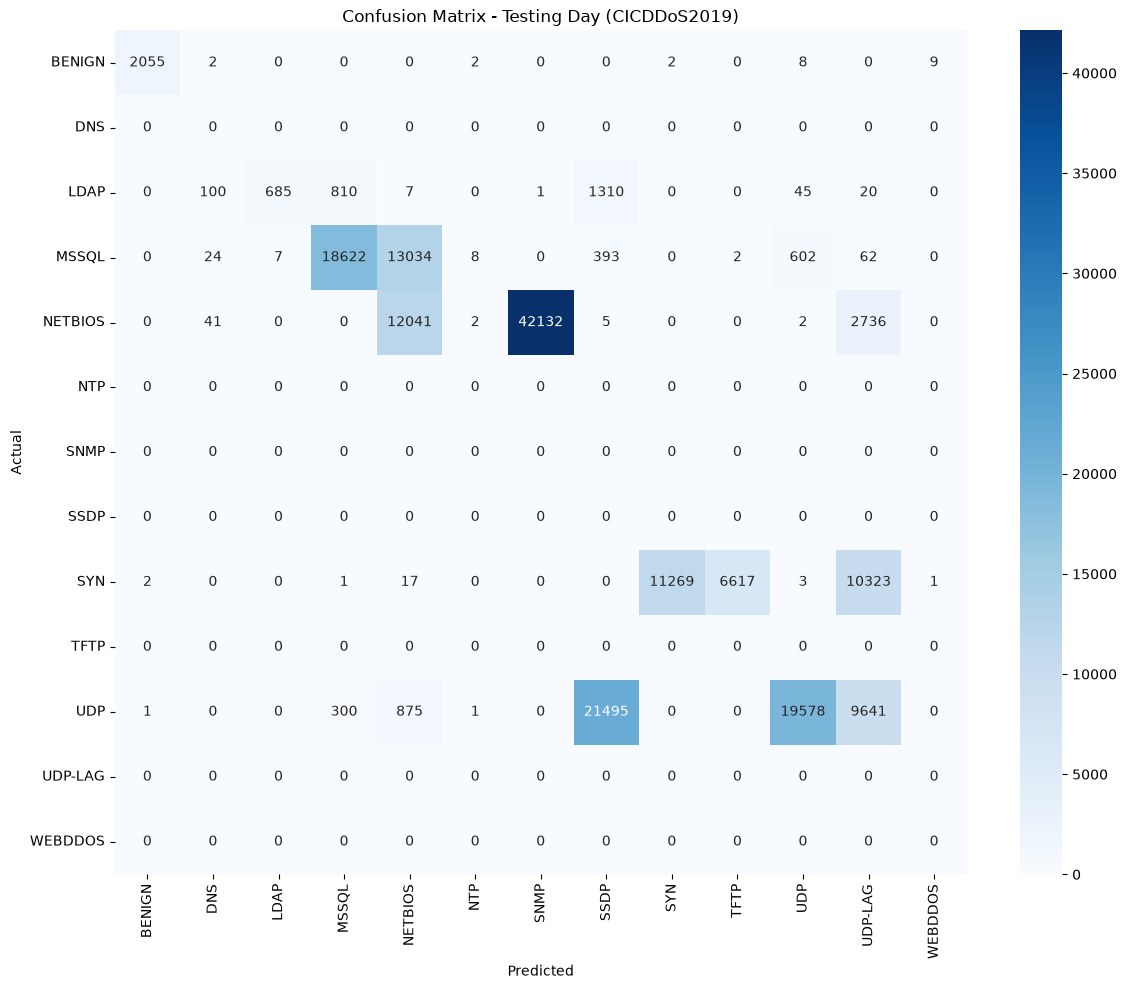

Saved: confusion_matrix.png


In [7]:
cm = confusion_matrix(y_test, y_pred, labels=present_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Testing Day (CICDDoS2019)')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

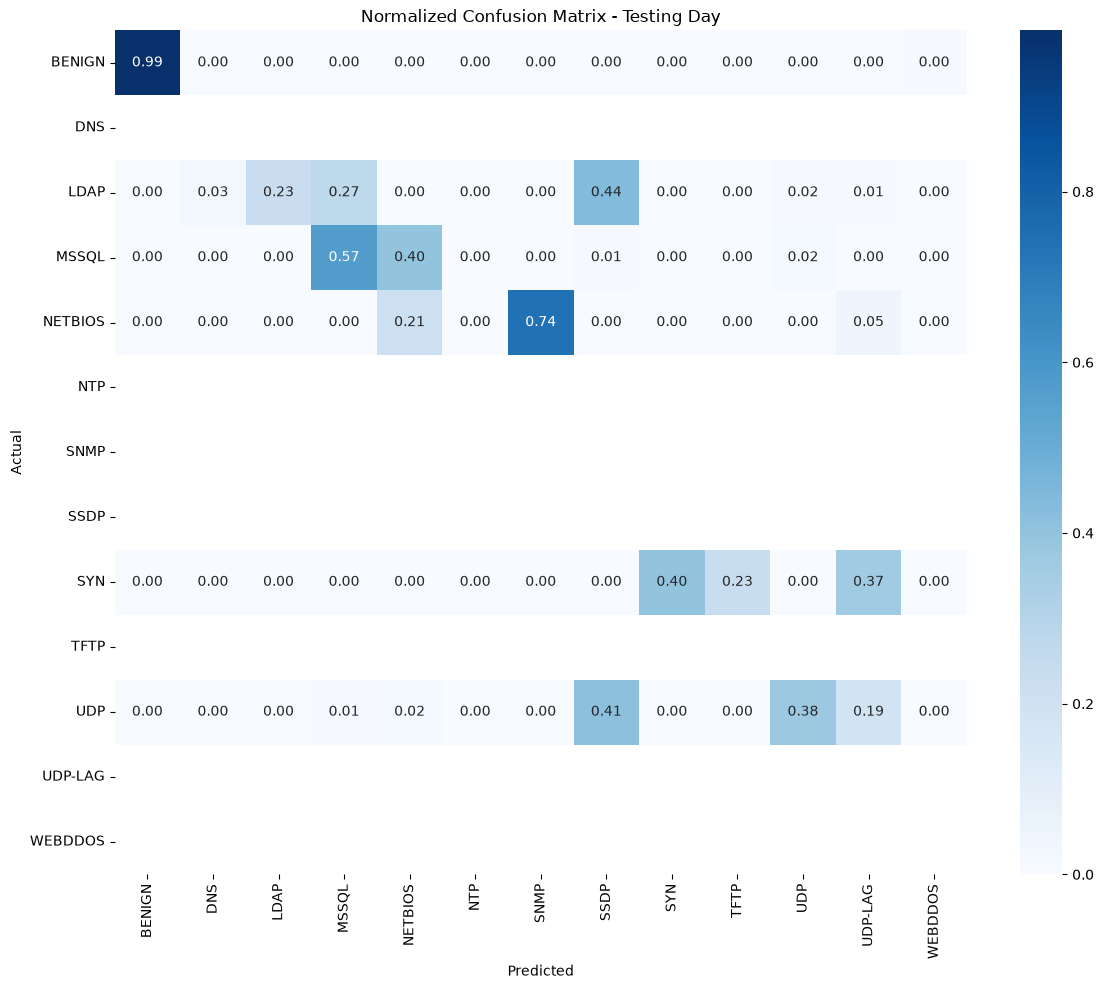

Saved: confusion_matrix_normalized.png


In [8]:
# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix - Testing Day')
plt.tight_layout()
plt.savefig('../data/confusion_matrix_normalized.png', dpi=150)
plt.show()
print('Saved: confusion_matrix_normalized.png')

## 6. Per-Class F1 Bar Chart

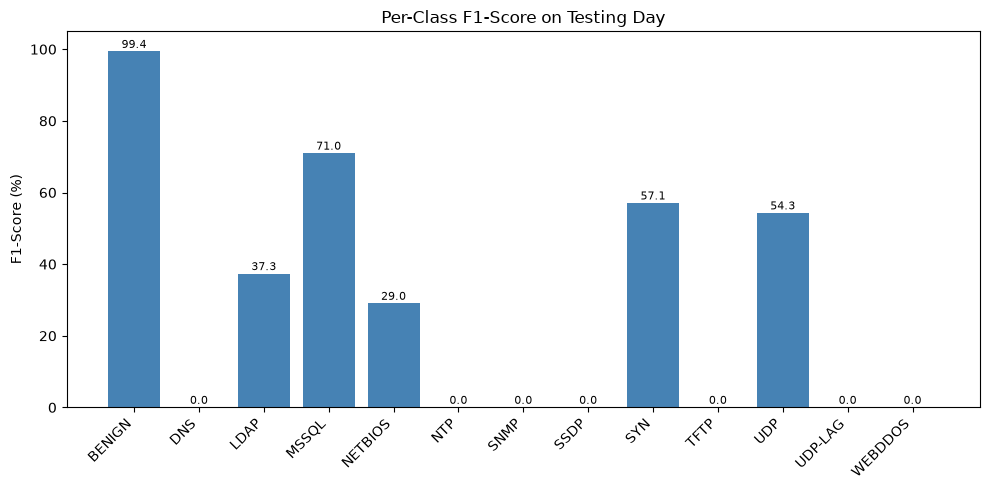

Saved: per_class_f1.png


In [9]:
from sklearn.metrics import f1_score as f1_per_class

f1_per = f1_per_class(y_test, y_pred, labels=present_labels, average=None)

plt.figure(figsize=(10, 5))
bars = plt.bar(present_names, f1_per * 100, color='steelblue')
plt.ylabel('F1-Score (%)')
plt.title('Per-Class F1-Score on Testing Day')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)
for bar, val in zip(bars, f1_per*100):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1, 
             f'{val:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../data/per_class_f1.png', dpi=150)
plt.show()
print('Saved: per_class_f1.png')

## 7. Summary & Save

In [10]:
# Save evaluation results
eval_results = {
    'accuracy': acc,
    'precision_macro': prec_macro,
    'recall_macro': rec_macro,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'f1_per_class': dict(zip(present_names, f1_per.tolist())),
    'confusion_matrix': cm.tolist(),
    'test_samples': len(y_test),
    'classes_evaluated': present_names
}

with open('../data/evaluation_results.pkl', 'wb') as f:
    pickle.dump(eval_results, f)

print('\n' + '='*60)
print('  FINAL SUMMARY')
print('='*60)
print(f'  Model: XGBoost multiclass ({train_results["model_size_kb"]:.1f} KB)')
print(f'  Training classes: {len(train_classes)}')
print(f'  Testing: {len(y_test):,} samples')
print(f'  Classes evaluated: {len(present_names)}')
print(f'  Overall Accuracy: {acc*100:.2f}%')
print(f'  F1-Score (macro): {f1_macro*100:.2f}%')
print(f'  Inference: {train_results["inference_ms"]:.1f} ms (100 samples)')
print('='*60)
print('\nSaved: evaluation_results.pkl')
print('\n=== All notebooks complete! ===')


  FINAL SUMMARY
  Model: XGBoost multiclass (4897.6 KB)
  Training classes: 13
  Testing: 174,893 samples
  Classes evaluated: 13
  Overall Accuracy: 36.74%
  F1-Score (macro): 26.77%
  Inference: 0.6 ms (100 samples)

Saved: evaluation_results.pkl

=== All notebooks complete! ===
